<a href="https://colab.research.google.com/github/asegura4488/MetodosComputacionales2026/blob/main/Semana9/AplicacionValoresSingulares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


VALORES SINGULARES
[21.47571739 10.1360372   4.98965036  3.34031458]

VARIANZA EXPLICADA
Componente 1: 76.87%
Componente 2: 17.12%
Componente 3: 4.15%
Componente 4: 1.86%

VARIANZA ACUMULADA
[0.7686774  0.93990948 0.98140383 1.        ]

DIRECCIONES PRINCIPALES
               PC1    PC2    PC3    PC4
Horas       -0.516  0.457 -0.010  0.725
Ejercicios  -0.504  0.514 -0.111 -0.685
Matematicas -0.503 -0.433  0.744 -0.075
Fisica      -0.476 -0.583 -0.659  0.020

UMBRALES
D2: 4.7589163367610015
Q: 0.8124158677826165

ESTUDIANTES DETECTADOS
      Horas  Ejercicios  Matematicas  Fisica      Tipo_real      D2      Q  Atipico_D2  Atipico_Q
4     4.104      14.269        2.632   2.505         Normal   4.861  0.060        True      False
10   23.000      68.000        5.000   4.900        Extremo  21.475  0.376        True      False
29   11.521      32.410        4.084   3.138         Normal   0.255  1.714       False       True
30   22.000      65.000        2.100   2.000  Inconsistente  76.56

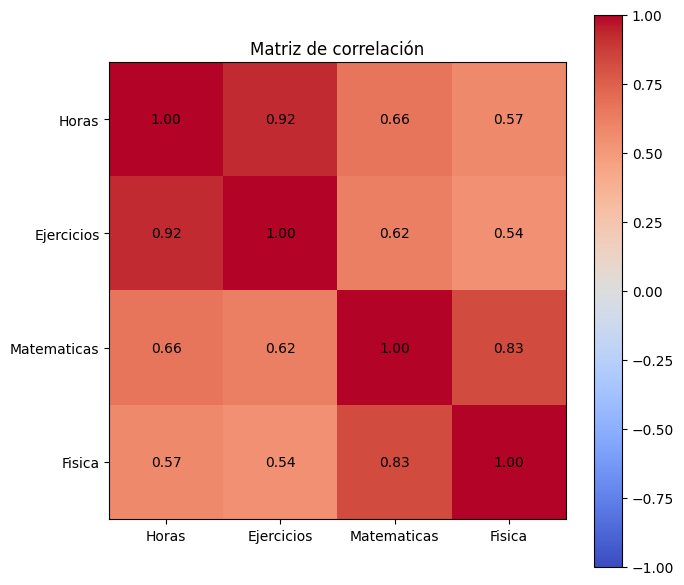

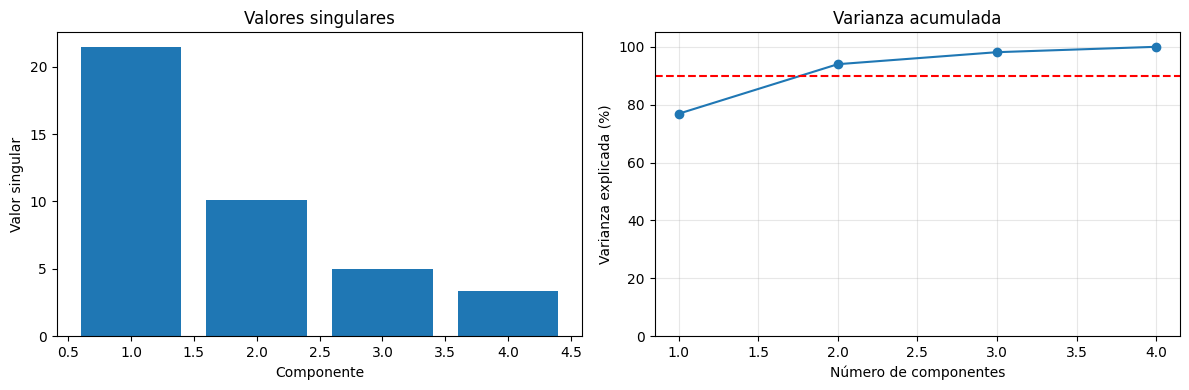

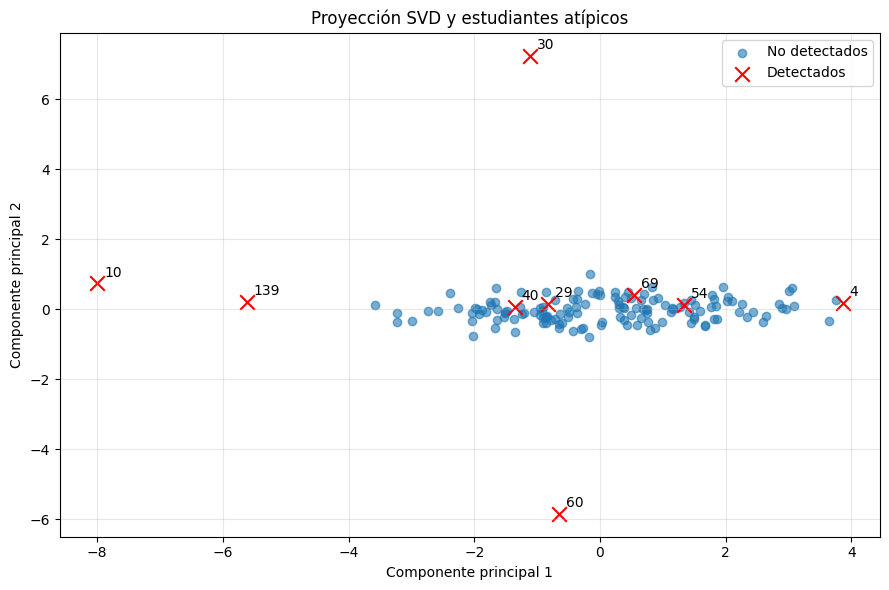

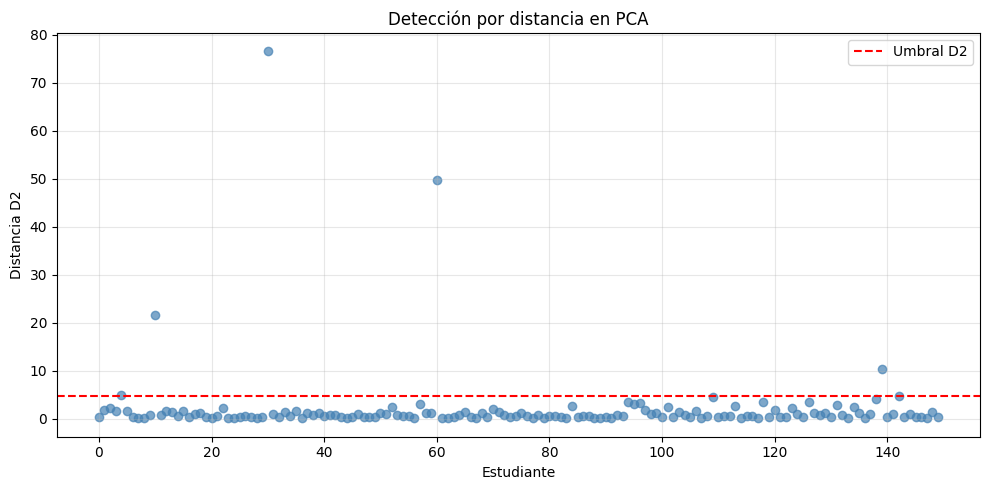

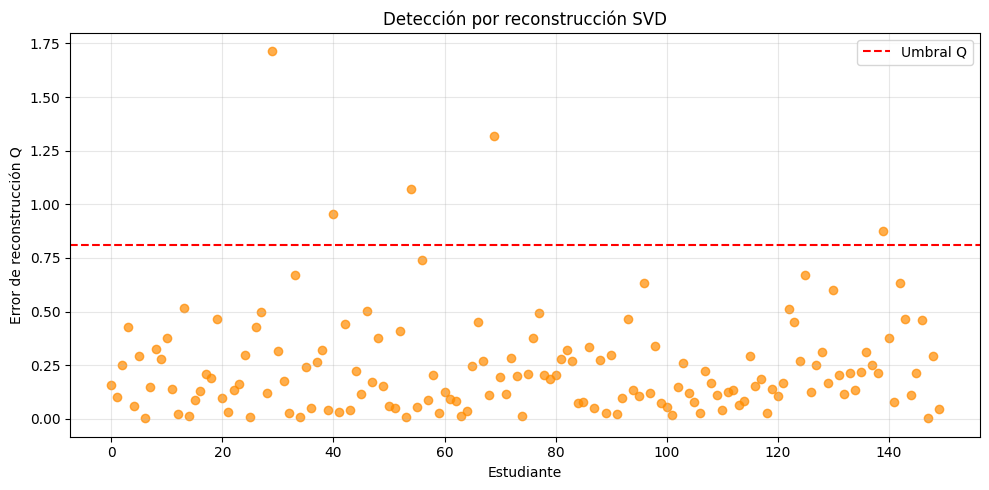

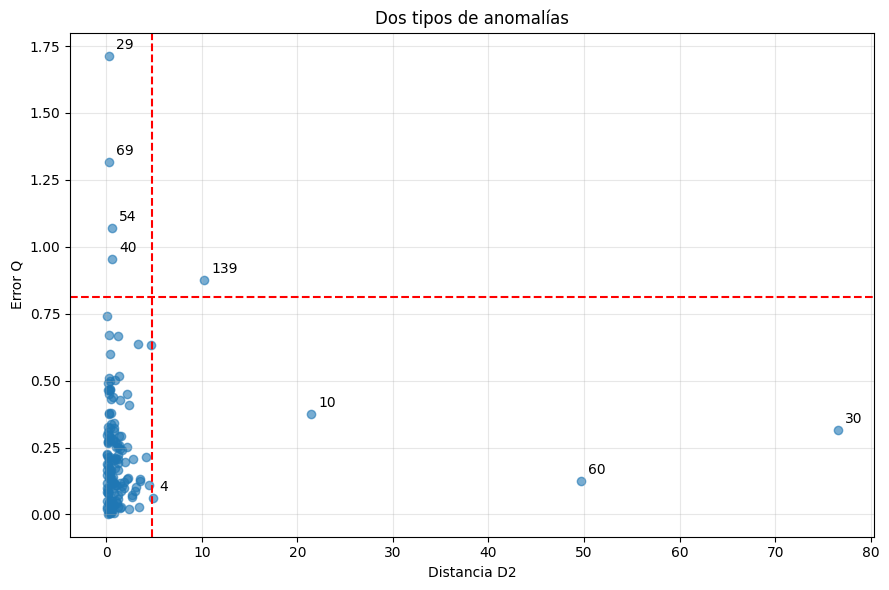


ANOMALÍAS INTRODUCIDAS
        Tipo_real      D2      Q  Atipico_D2  Atipico_Q  Atipico
10        Extremo  21.475  0.376        True      False     True
30  Inconsistente  76.562  0.317        True      False     True
60  Inconsistente  49.674  0.126        True      False     True

Archivo generado: estudiantes_svd_resultados.csv


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

# =========================================================
# 1. GENERACIÓN DE DATOS
# =========================================================

rng = np.random.default_rng(42)

N = 150

# Factor latente de dedicación académica
dedicacion = rng.normal(0, 1, N)

# Variables académicas
horas = 10 + 3*dedicacion + rng.normal(0, 0.8, N)
ejercicios = 30 + 8*dedicacion + rng.normal(0, 2, N)

matematicas = (
    3.5 + 0.45*dedicacion
    + rng.normal(0, 0.15, N)
)

fisica = (
    3.4 + 0.40*dedicacion
    + rng.normal(0, 0.18, N)
)

# Datos de estudiantes
df = pd.DataFrame({
    "Horas": horas,
    "Ejercicios": ejercicios,
    "Matematicas": matematicas,
    "Fisica": fisica
})

df["Tipo_real"] = "Normal"

# =========================================================
# 2. INTRODUCIMOS ESTUDIANTES ATÍPICOS
# =========================================================

# Estudiante extremo: muy alta dedicación y notas
df.loc[10, ["Horas", "Ejercicios",
            "Matematicas", "Fisica"]] = [23, 68, 5.0, 4.9]
df.loc[10, "Tipo_real"] = "Extremo"

# Estudiante inconsistente:
# mucha dedicación pero calificaciones bajas
df.loc[30, ["Horas", "Ejercicios",
            "Matematicas", "Fisica"]] = [22, 65, 2.1, 2.0]
df.loc[30, "Tipo_real"] = "Inconsistente"

# Otro perfil inconsistente:
# poca dedicación pero notas altas
df.loc[60, ["Horas", "Ejercicios",
            "Matematicas", "Fisica"]] = [3, 7, 4.9, 4.8]
df.loc[60, "Tipo_real"] = "Inconsistente"

variables = [
    "Horas", "Ejercicios", "Matematicas", "Fisica"
]

X_original = df[variables].values

# =========================================================
# 3. ESTANDARIZACIÓN
# =========================================================

scaler = StandardScaler()
X = scaler.fit_transform(X_original)

# =========================================================
# 4. DESCOMPOSICIÓN SVD
# =========================================================

U, S, VT = np.linalg.svd(
    X, full_matrices=False
)

print("\nVALORES SINGULARES")
print(S)

# Varianza explicada
varianza = S**2 / np.sum(S**2)

print("\nVARIANZA EXPLICADA")
for i, v in enumerate(varianza):
    print(f"Componente {i+1}: {100*v:.2f}%")

print("\nVARIANZA ACUMULADA")
print(np.cumsum(varianza))

# Coeficientes de las componentes
print("\nDIRECCIONES PRINCIPALES")
print(pd.DataFrame(
    VT.T,
    index=variables,
    columns=[f"PC{i+1}" for i in range(4)]
).round(3))

# =========================================================
# 5. PROYECCIÓN SOBRE DOS COMPONENTES
# =========================================================

k = 2

Vk = VT[:k, :].T
Z = X @ Vk

# Reconstrucción de los datos
X_rec = Z @ Vk.T

# =========================================================
# 6. DOS MÉTODOS PARA DETECTAR ANOMALÍAS
# =========================================================

# Método A: distancia de Mahalanobis
# en el espacio principal
lambda_k = S[:k]**2 / (N-1)

D2 = np.sum(
    Z**2 / lambda_k,
    axis=1
)

# Método B: error cuadrático de reconstrucción
Q = np.sum(
    (X - X_rec)**2,
    axis=1
)

df["PC1"] = Z[:, 0]
df["PC2"] = Z[:, 1]
df["D2"] = D2
df["Q"] = Q

# Umbrales empíricos: percentil 97
# Son exploratorios, no pruebas estadísticas.
umbral_D2 = np.percentile(D2, 97)
umbral_Q = np.percentile(Q, 97)

df["Atipico_D2"] = D2 > umbral_D2
df["Atipico_Q"] = Q > umbral_Q

df["Atipico"] = (
    df["Atipico_D2"] | df["Atipico_Q"]
)

print("\nUMBRALES")
print("D2:", umbral_D2)
print("Q:", umbral_Q)

print("\nESTUDIANTES DETECTADOS")
columnas = variables + [
    "Tipo_real", "D2", "Q",
    "Atipico_D2", "Atipico_Q"
]

print(
    df.loc[df["Atipico"], columnas]
    .round(3)
    .to_string()
)

# =========================================================
# 7. GRÁFICA: MATRIZ DE CORRELACIÓN
# =========================================================

corr = df[variables].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    corr, cmap="coolwarm", vmin=-1, vmax=1
)

ax.set_xticks(range(4), variables)
ax.set_yticks(range(4), variables)

for i in range(4):
    for j in range(4):
        ax.text(
            j, i, f"{corr.iloc[i,j]:.2f}",
            ha="center", va="center"
        )

plt.colorbar(im, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

# =========================================================
# 8. GRÁFICA: ESPECTRO SINGULAR
# =========================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(range(1, 5), S)
ax[0].set_title("Valores singulares")
ax[0].set_xlabel("Componente")
ax[0].set_ylabel("Valor singular")

ax[1].plot(
    range(1, 5),
    np.cumsum(varianza)*100,
    "o-"
)
ax[1].axhline(90, ls="--", color="red")
ax[1].set_ylim(0, 105)
ax[1].set_title("Varianza acumulada")
ax[1].set_xlabel("Número de componentes")
ax[1].set_ylabel("Varianza explicada (%)")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# 9. GRÁFICA: DATOS PROYECTADOS
# =========================================================

fig, ax = plt.subplots(figsize=(9, 6))

normales = ~df["Atipico"]
atipicos = df["Atipico"]

ax.scatter(
    df.loc[normales, "PC1"],
    df.loc[normales, "PC2"],
    alpha=0.6, label="No detectados"
)

ax.scatter(
    df.loc[atipicos, "PC1"],
    df.loc[atipicos, "PC2"],
    s=110, marker="x", color="red",
    label="Detectados"
)

for i in df.index[df["Atipico"]]:
    ax.annotate(
        str(i),
        (df.loc[i, "PC1"], df.loc[i, "PC2"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.set_title("Proyección SVD y estudiantes atípicos")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 10. GRÁFICA: DISTANCIA D2
# =========================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    range(N), D2, c="steelblue", alpha=0.7
)

ax.axhline(
    umbral_D2, color="red",
    linestyle="--", label="Umbral D2"
)

ax.set_xlabel("Estudiante")
ax.set_ylabel("Distancia D2")
ax.set_title("Detección por distancia en PCA")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 11. GRÁFICA: ERROR DE RECONSTRUCCIÓN
# =========================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    range(N), Q, c="darkorange", alpha=0.7
)

ax.axhline(
    umbral_Q, color="red",
    linestyle="--", label="Umbral Q"
)

ax.set_xlabel("Estudiante")
ax.set_ylabel("Error de reconstrucción Q")
ax.set_title("Detección por reconstrucción SVD")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 12. GRÁFICA: COMPARACIÓN D2 vs Q
# =========================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(D2, Q, alpha=0.6)

ax.axvline(
    umbral_D2, color="red", linestyle="--"
)
ax.axhline(
    umbral_Q, color="red", linestyle="--"
)

for i in df.index[df["Atipico"]]:
    ax.annotate(
        str(i), (D2[i], Q[i]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Distancia D2")
ax.set_ylabel("Error Q")
ax.set_title("Dos tipos de anomalías")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 13. COMPARACIÓN CON LAS ANOMALÍAS INTRODUCIDAS
# =========================================================

print("\nANOMALÍAS INTRODUCIDAS")
print(
    df.loc[
        df["Tipo_real"] != "Normal",
        ["Tipo_real", "D2", "Q",
         "Atipico_D2", "Atipico_Q", "Atipico"]
    ].round(3).to_string()
)

# =========================================================
# 14. GUARDAR RESULTADOS
# =========================================================

df.to_csv(
    "estudiantes_svd_resultados.csv",
    index=False
)

print("\nArchivo generado: estudiantes_svd_resultados.csv")